# TP1: Visualisation et analyse de données climatiques

Dans ce TP, vous allez utiliser des données publiques mises à disposition par des instituts de recherche internationaux. Ces données concernent: 
- la température moyenne à la surface de la terre 
- les concentrations de CO2, réelles ou estimées, dans l'atmosphère. 

Il s'agira :
- de visualiser l'évolution de ces quantités sur des intervalles de temps parfois très différents, de dizaines d'années à presque un million d'années. On parlera ainsi de **séries temporelles**.
- d'appréhender certaines régularités et aussi des tendancesdans sur ces séries, et de voir comment on peut ou non proposer un discours scientifique dessus
- enfin, de voir s'il y a des relations entre CO2 et température

**Utilisation du notebook**  
Ce jupyter-notebook constituera le rendu de TP.  
Vous répondrez directement dans les cellules avec 
- du texte (passer alors en markdown - raccourci clavier "M") 
- du code, à compléter ou à adapter de codes précédents.

*__Avertissement important__: ce TP ne se terminera pas, pour le moment, par l'établissement d'un lien indiscutable entre CO2 et température. Le but est surtout de constater que des outils simples ne permettent pas de conclure. Mais il ne s'agit en rien d'un message climatosceptique. Sur ce point, la science est claire et les différents rapports du GIEC ont établi l'origine anthropique du changement climatique. Les preuves scientifiques utilisées sont plus complexes et s'appuient sur des processus sociaux de consensus dans une communauté scientifique.*

In [1]:
# Librairies
import csv
import matplotlib.pyplot as plt
import numpy as np

# 1. Evolution du CO2 depuis 1958

On va travailler sur les données disponibles sur le site de l'institut d'Océanographie de San Diego (USA)
https://scrippsco2.ucsd.edu/data/atmospheric_co2/primary_mlo_co2_record.html

**Question 1**
- Télécharger et enregistrer le fichier .csv disponible sur le site. 
- Ouvrir le fichier avec le tableur de votre choix et un formattage adéquat. 
- Repérer les colonnes qui vont être pertinentes pour l'analyse, c'est à dire 1) des informations temporelles, 2) des informations sur la quantité de CO2

**Réponse:**
Le fichier .csv disponible sur leur site s'appelle "monthly_in_situ_co2_mlo.csv". 
- Il y a 11 colonnes, 10 colonnes de données numériques et une colonne avec un identifiant de station d'échantillonnage. Les colonnes pertinentes pour l'analyse sont les 10 première colonnes. On s'assure que les formats, dates et nombres sont cohérents. 
- Les colonnes 1 à 4 sont des dates, ce sont les informations temporelles, en années en mois, date excel, année décimal.  
- Les informations correspondantes au CO2 sont les colonnes 5 à 10. 

**Question 2**
- Utiliser et compléter le code suivant pour ouvrir le .csv et stocker le contenu dans la liste `rows`

In [2]:
filename = "monthly_in_situ_co2_mlo.csv"# à compléter
with open(filename, newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='|')
    rows = []
    for row in reader:
        rows.append(row)
print(rows[0:4])

[['  Yr', ' Mn', '    Date', '      Date', '     CO2', 'seasonally', '        fit', '  seasonally', '      CO2', ' seasonally', ' Sta'], ['    ', '   ', '        ', '          ', '        ', '  adjusted', '           ', 'adjusted fit', '   filled', 'adjusted filled', ''], ['    ', '   ', '   Excel', '          ', '   [ppm]', '    [ppm] ', '      [ppm]', '    [ppm]', '       [ppm]', '    [ppm]', ''], ['1958', '3', '21259', '  1958.2027', '  315.71', '   314.44', '     316.20', '   314.91', '     315.71', '   314.44', ' MLO']]


- Quelle est la structure de `rows` ? 
- Vérifier que le contenu est cohérent avec ce que vous avez vu à la question 1. 
- A quelle indice `i_debut` trouve-t-on les premières valeurs numériques qui nous intéressent ?

- rows est un tableau. La fonction print présente les colonnes de 0 à 4 du fichier csv, ce qui correspond à un texte de présentation sur les données CSV. 
- Le contenu semble cohérent avec ce qu'il y a dans le fichier csv lui nême, mais cela ne correspond pas aux valeurs des colonnes pertinentes pour l'analyse.
- on trouve les valeurs numériques qui nous intéressent à la ligne ou rang 64, c'est à dire à partir de l'indice 63

In [3]:
i_debut = 64 # à compléter

**Question 3**  
- En utilisant la question 1 donner les indices des colonnes pour les informations temporelles et de CO2 et créez ainsi deux listes `temps` et `co2`.

In [4]:
temps = []
co2 = []
i_temps = 0 # On choisit la première colonne en année
i_co2 =  4 # On choisit la colonne de données CO2 brut
for i, row in enumerate(rows):
    if i>=i_debut:
        temps.append(float(row[i_temps])) 
        co2.append(float(row[i_co2])) 

- En utilisant la fonction `plot` de matplotlib, **afficher le graphique** donnant l'évolution du CO2 en fonction du temps. 

*Il est possible que vous ayez un affichage abhérent: cela correspond vraisemblablement à un mauvais choix pour les colonnes du tableau.*

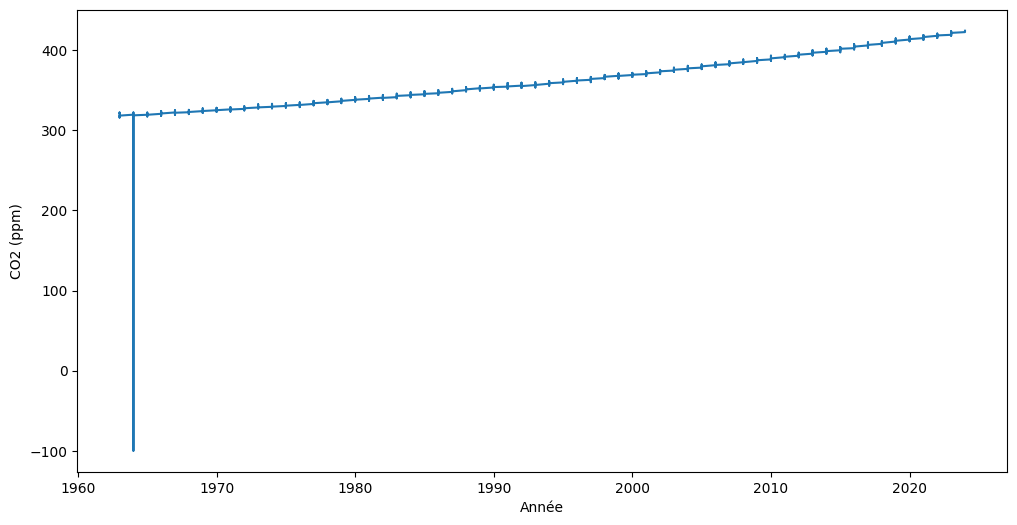

In [5]:
plt.figure(figsize=(12,6))
plt.xlabel("Année")
plt.ylabel("CO2 (ppm)")
plt.plot(temps,co2) # à compléter

**Question 4 (bonus)**
- On va utiliser la transformée de Fourier pour étudier précisément les régularités observées sur la figure. Il s'agit de construire un spectre qui donne la composition d'une série temporelle en signaux de différentes fréquences, comme pour le signal audio par exemple.

In [6]:
spectrum = np.abs(np.fft.rfft(co2))

- On affiche ensuite le spectre en enlevant la première valeur qui correspond à la somme des valeurs du signal et n'est pas informative.

Text(0.5, 0, 'Fréquence')

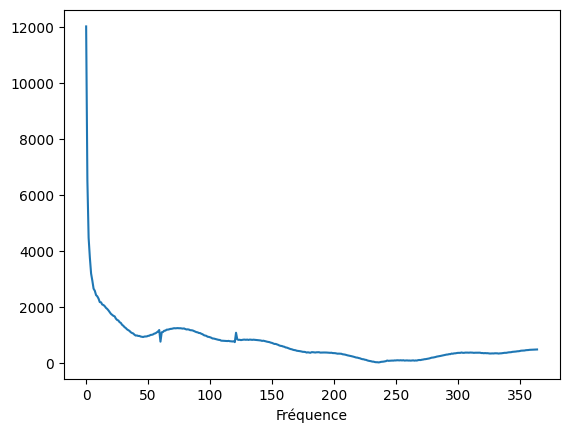

In [7]:
plt.plot(spectrum[1:])
plt.xlabel('Fréquence')

- Le résultat peut être rendu encore plus intéressant à visualier en utilisant une échelle logarithmique pour l'axe $y$.

Text(0.5, 0, 'Fréquence')

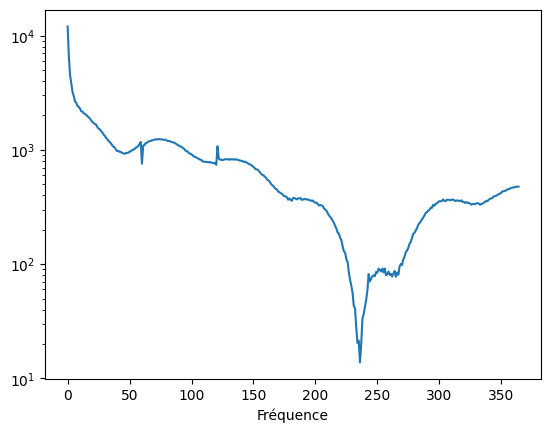

In [8]:
plt.semilogy(spectrum[1:])
plt.xlabel('Fréquence')

- Les pics correspondent aux périodicités observées dans le signal de départ. On veut savoir à quelle période, en années, ces pics correspondent. La période est l'inverse de la fréquence. Mais la fréquence donnée ici dépend de l'échantillonage du signal, c'est à dire du nombre d'années entre deux instants consécutifs. Ici ce nombre est constant.  
- Compléter le code suivant et interpréter la valeur trouvée pour la période (en années). La variable `temps_ech` correspond au temps écoulé entre deux échantillons quelconques, alors que `freq_pic` peut être estimé en vérifiant la distance entre deux pics quelconques dans `spectrum`.

In [16]:
temps_ech = 1/12 # le pas d'échantillonage = temps entre deux mesures consécutives. Dans notre fichier, les données sont mensuelles donc 1/12
freq_ech = 1/temps_ech
freq_pic = 50 #L'écart entre deux plus pics semble être de 10
periode = len(rows)*temps_ech / freq_pic
print(str(periode) + " (années)")

1.8283333333333331 (années)


**Votre interprétation :**

La période en années est T= 1.46 années , cela correspond à environ 1 ans et 5 mois.

**On recopie les variables de cet exercice car elles seront utiles plus tard**

In [17]:
import copy
temps_actuel = copy.deepcopy(temps)
co2_actuel = copy.deepcopy(co2)

# 2. Evolution du CO2 depuis 800000 ans

On considère ici des données issues de carottages dans la glace de l'Antarctique et qui permettent de retracer la concentration du CO2 dans l'atmosphère sur des échelles de temps très importantes:
https://www.ncei.noaa.gov/access/paleo-search/study/6091

**Question 1**

- En utilisant les questions 2 et 3 de la partie précédente, ouvrir `edc3-composite-co2-2008-noaa.csv` et récupérer les données numériques dans des listes qu'on nommera comme précédemment `temps` et `co2`

*Attention, l'unité de temps ici est indiquée comme `gas_ageBP	gas age,,,calendar year before present`. Il faut donc rétablir la bonne chronologie quand vous récupérez les valeurs d'années.*

In [18]:
filename = "edc3-composite-co2-2008-noaa.csv"
temps = []
co2 = []
i_debut = 1
i_temps = 0
i_co2 = 1
#remarque les noms des variables interfèrent avec les noms des variables déclarées précédemment
with open(filename, newline='') as csvfile : 
    reader = csv.reader(csvfile, delimiter=',', quotechar='|')
    rows =[]
    for row in reader :
        rows.append(row)

for i, row in enumerate(rows):
    if i>=i_debut:
        temps.append(float(row[i_temps])) 
        co2.append(float(row[i_co2])) 

In [19]:
temps = list(reversed(temps)) # Il faut inverser le temps, car les données commencent par les plus récentes 
co2=list(reversed(co2))

- Afficher ensuite l'évolution du CO2 avec le temps. 

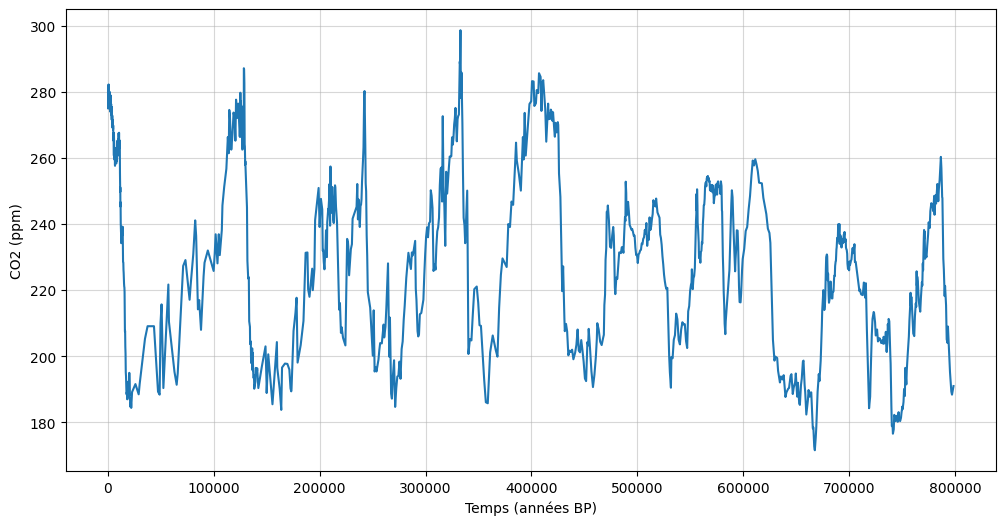

In [20]:
plt.figure(figsize=(12,6))
plt.xlabel("Temps (années BP)")
plt.ylabel("CO2 (ppm)")
plt.grid(True, alpha=0.5)
plt.plot(temps, co2)

**Question 2**
- Dans la figure précédente on observe des pseudo-périodicités qu'on aimerait quantifier avec une analyse de Fourier. Mais pour cela, il faut s'assurer que l'échantillonage du signal est régulier. Est ce le cas ? Pour répondre à cette question, vous pouvez visualiser les différences entre les valeurs adjacentes dans `temps`.

In [21]:
# Pour avoir un échantillonage régulier du signal, on doit s'assurer que les points sont bien répartis dans le temps

difference_temps = np.diff(temps)

print(difference_temps)

[-1413.  -632. -1265. ...  -116.   -11.  -131.]


On calcule les différences entre les valeurs adjacentes dans temps avec la fonction np.diff(). En affichant les valeurson constate que les écarts ne sont pas constants. L'échantillonnage n'est donc pas régulier.

- Pour pallier ce problème, on va interpoler les données en utilisant la fonction `interp` de `numpy`. L'idée est de créer un échantillonnage temporel régulier (variable `pas`) de la période considérée et de "prédire", à partir des données irrégulières, la valeur de CO2 sur ces points de mesure fictifs.

In [22]:
pas =  np.mean(difference_temps)#échantillonage temporel régulier
print(pas)
xnew = np.arange(np.min(temps),np.max(temps),pas)
ynew = np.interp(xnew, temps, co2)

-729.1095890410959


- Vérifier que les données interpolées `ynew` sont visuellement identiques aux données d'origine

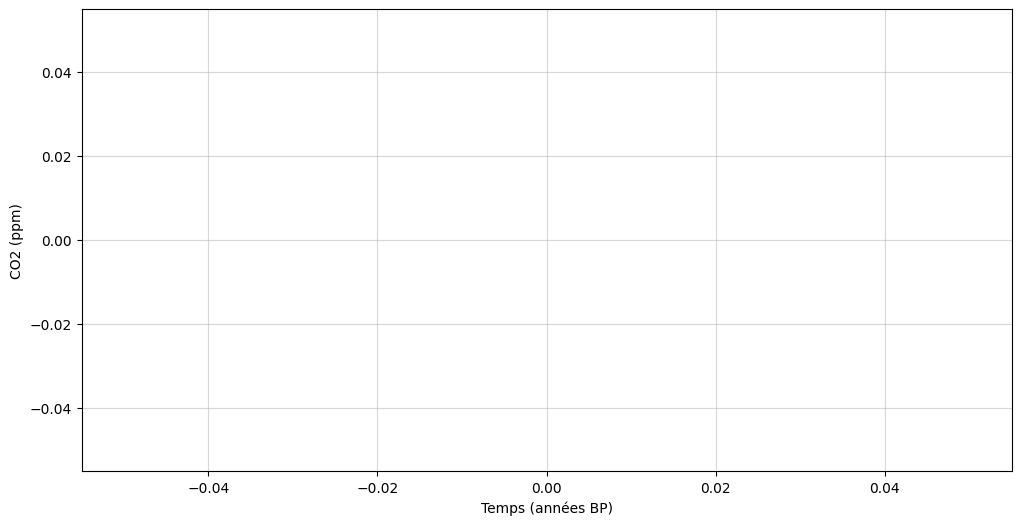

In [23]:
plt.figure(figsize=(12,6))
plt.xlabel("Temps (années BP)")
plt.ylabel("CO2 (ppm)")
plt.grid(True, alpha=0.5)
plt.plot(xnew, ynew)

**Question 3 (bonus)**

- Calculer et afficher la transformée de Fourier du signal interpolé comme dans la question 4 de la partie 1.
- Identifier des pics. Pour cela, vous pourrez essayer `semilogy` ou `semilogx` et restreindre les plages de valeurs du spectre (zoom).

In [434]:
# à compléter

- A quelle(s) période(s) correspond(ent) le(s) pic(s). Commenter par rapport à ce qui a été vu en cours

In [435]:
# à compléter

## Conclusion des exercices 1 et 2
**Pour finir, on affiche ces données historiques avec celles de l'ère contemporaine.**

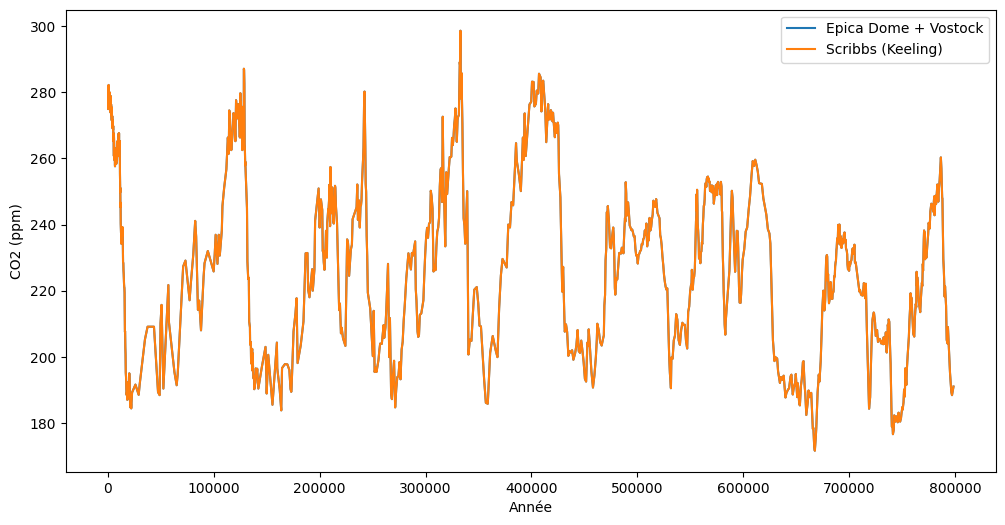

In [48]:
plt.figure(figsize=(12,6))

plt.plot(temps_actuel,co2_actuel)
plt.xlabel("Année")
plt.ylabel("CO2 (ppm)")
plt.plot(temps,co2)
plt.legend(["Epica Dome + Vostock","Scribbs (Keeling)"])

**Commenter ce graphique**

*à compléter*

# 3. Evolution de la température depuis 1850

On travaille maintenant sur des données historiques de température issues de https://crudata.uea.ac.uk/cru/data//temperature/#filfor . Vous trouverez sur Ametice le fichier `HadCRUT5.0Analysis_gl.csv` qui donne la température globale à la surface de la terre (hémisphère nord et sud) depuis 1850.

**Question 1**

- Lire le fichier `.csv` et stocker les valeurs dans deux tableaux alignés `annees` et `temperature`, comme nous avons fait pour le temps et le CO2 dans les deux exercices précédents.

In [53]:
import numpy as np
import csv 

filename = "HadCRUT5.0Analysis_gl.csv"

#tableaux annes et temperature 
annees = []
temperature = []

i_debut = 1 
i_annees = 0 
i_temperature = 1

with open(filename, newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    rows = []
    for row in reader: 
        rows.append(row)
        
for i, row in enumerate(rows):
    if i >= i_debut:
        annees.append(float(row[i_annees]))
        temperature.append(float(row[i_temperature]))
        
#on vérifie nos tableaux années et température pour les 10 premiers éléments : 

print(annees[:10])
print(temperature[:10])

[1851.0, 1852.0, 1853.0, 1854.0, 1855.0, 1856.0, 1857.0, 1858.0, 1859.0, 1860.0]
[-0.2334166666666667, -0.23483333333333334, -0.27025, -0.2914166666666667, -0.29683333333333334, -0.3204166666666667, -0.4673333333333333, -0.38891666666666663, -0.28133333333333327, -0.3900833333333333]


- Afficher la température en fonction de l'année. 

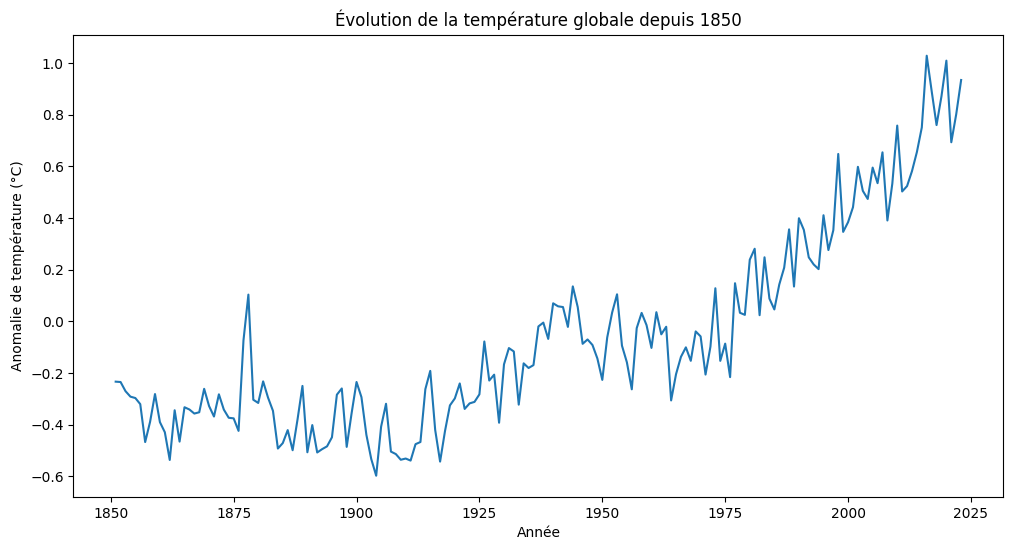

In [54]:
plt.figure(figsize=(12,6))
plt.plot(annees, temperature)

plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")
plt.title("Évolution de la température globale depuis 1850")

plt.show()

* Pourquoi y a t-il des températures négatives ? Comment doit-on interpréter les valeurs de température ?

**Votre réponse :**

Les données correspondent à l'évolution de l'anomalie de température en degré celsius en fonction des années depuis 1850. L'anomalie correspond à la différence entre la température mesurée aux hémisphères et la température moyenne de référence. Une anomalie positive signifies que que la température mesurée est plus grande que la température de référence alors qu'une anomalie négative signifie que la température mesurée est inférieure à la température moyenne de référence.

- Que pensez vous de l'évolution de la température depuis 1850 ?

**Votre réponse :**

On observe une augmentation de la température globale (tempréature moyenne de référence et température mesurée) depuis 1850. L'évolution est plus marquée aux alentours de l'année 1925 puis de l'année 1975, ce qui pourrait correspondre aux deux révolutions industrielles. Les révolutions indsutrielles sont des périodes d'augmentation rapide des émissions de gaz à effet de serre dues aux activités humaines de l'industrialisation.

# 4. Lien entre CO2 et température

On va terminer ici en essayant de voir un lien entre CO2 et température.  
On part des données de CO2 disponibles ici
https://data.csiro.au/collection/csiro:37077v1
et vous utiliserez le fichier `co2_2000y.csv` disponible sur Ametice.

**Question 1**

- Récupérer les données du `.csv` dans deux tableaux alignés comme dans les exercices précédents

In [76]:
import numpy as np
import csv 

filename = "co2_2000y.csv"

#tableaux annes et temperature 
annees = []
co2 = []

i_debut = 1 
i_annees = 0 
i_co2 = 1

with open(filename, newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=' ')
    rows = []
    for row in reader: 
        rows.append(row)
        
for i, row in enumerate(rows):
    if i >= i_debut:
        ligne = row[0].split()
        annees.append(float(ligne[0]))
        co2.append(float(ligne[1]))
        
#on vérifie nos tableaux années et co2 pour les 10 premiers éléments : 

print(annees[:10])
print(co2[:10])

[1996.0, 1994.0, 1993.0, 1992.0, 1991.0, 1991.0, 1990.0, 1989.0, 1989.0, 1988.0]
[359.87, 357.24, 354.6, 353.89, 352.6, 352.0, 351.4, 349.92, 349.8, 347.8]


- Afficher la courbe de la température et du CO2 sur le même graphique en veillant à avoir deux systèmes d'axe séparés. Que remarquez vous ?

*Vous trouverez un exemple ici: https://matplotlib.org/stable/gallery/subplots_axes_and_figures/two_scales.html*

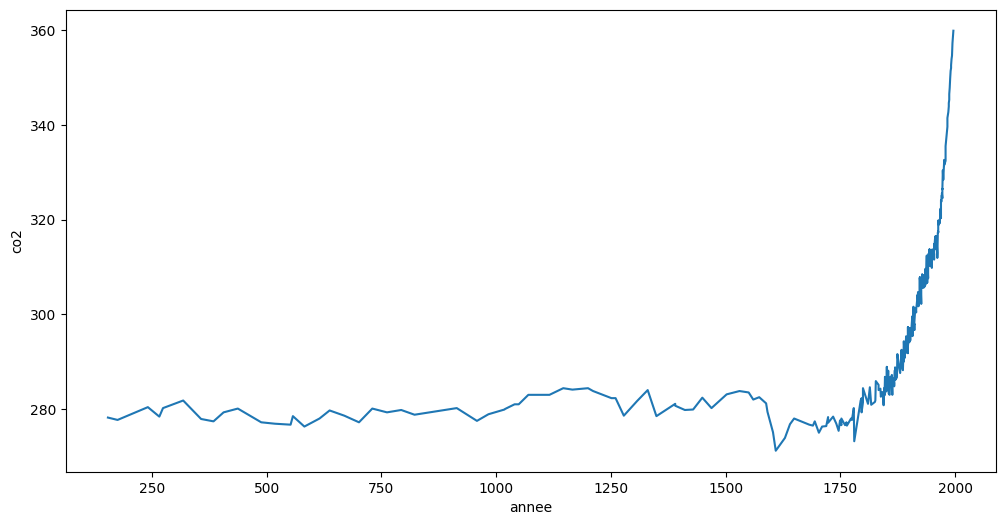

In [77]:
# à compléter
plt.figure(figsize=(12,6))
plt.plot(annees,co2)

plt.xlabel("annee")
plt.ylabel("co2")
plt.show()

*Réponse*

**Question 2**

- En fait le fichier `co2_2000y.csv` souffre de deux inconvénients, il y a des années manquantes et pour certaines années plusieurs mesures. On va régler ce problème en utilisant une interpolation comme pour la question 2 de la partie 2. Générer ainsi des mesures de CO2 pour la période allant de 1850 à 1996 inclus. N'oubliez pas d'inverser les tableaux d'années et CO2 pour que l'interpolation soit correcte.

In [70]:
# à compléter

- Pour cette période 1850-1996, représenter la température en fonction du CO2 et calculer la corrélation entre ces deux variables.

In [244]:
C = np.corrcoef() # à compléter
print("On trouve une corrélation de "+str(C[0,1]))

TypeError: corrcoef() missing 1 required positional argument: 'x'

- Que peut-on conclure de cette analyse ?

**Votre réponse :**

*à compléter*